# 🔎 Phase 4: Final Evaluation & Feature Importance
**Author:** Kyrylo Kudrevych

Welcome to the final step of the Poznań Rent Predictor project! 🏁

### 🎯 What are we doing here?
We have successfully trained our winning CatBoost model and saved it. However, a good Data Scientist doesn't just hand over a "black box" model. We need to understand *how* it makes decisions and ensure it is safe for real users to interact with.

In this notebook, we will:
* **Analyze Feature Importance:** Discover exactly which factors (like area or location) drive rent prices in Poznań the most.
* **Wrap up the project!**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

# 1. Load the training data columns (to get the feature names)
df = pd.read_parquet('notebooks_data/data_ready_for_ml.parquet')
X = df.drop(columns=['true_price'])
feature_names = X.columns

# 2. Load our winning CatBoost model
model_path = '../models/catboost_housing_model.pkl'
with open(model_path, 'rb') as file:
    cat_model = pickle.load(file)

print("Data and Model loaded successfully!")

Data and Model loaded successfully!


## 📊 1. Feature Importance: What drives the price?
Machine learning models shouldn't be a mystery. We can actually ask our CatBoost model to rank the features it relied on the most when calculating rent prices.

Let's extract these weights and plot the **Top 10 Drivers of Real Estate Prices** in Poznań.

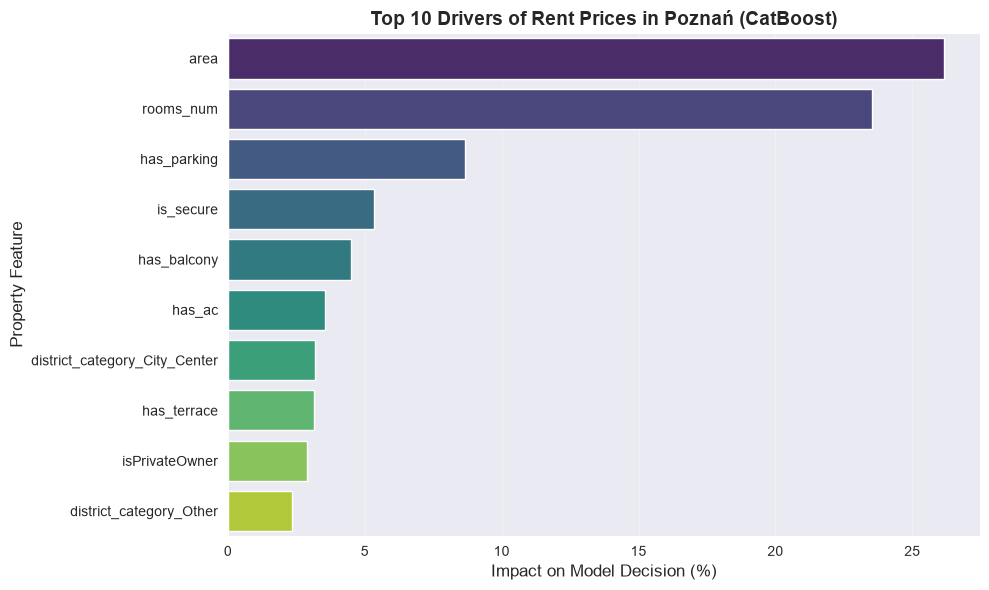

In [4]:
# Get feature importances directly from CatBoost
importances = cat_model.get_feature_importance()

# Create a clean DataFrame to view them
feature_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Sort by most important
feature_df = feature_df.sort_values(by='Importance', ascending=False).head(10)

# Plot the results
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_df, palette='viridis', hue='Feature', legend=False)
plt.title('Top 10 Drivers of Rent Prices in Poznań (CatBoost)', fontsize=14, fontweight='bold')
plt.xlabel('Impact on Model Decision (%)', fontsize=12)
plt.ylabel('Property Feature', fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 💡 2. Project Conclusion & Key Findings

By breaking our project down into distinct steps-Cleaning, Tuning, Training, and Evaluating - we established pipeline.

**Key Takeaways:**
1. **Solid Accuracy:** Our optimized CatBoost model achieved a Mean Absolute Error (MAE) of **~307 PLN**. This means that, on average, our AI can predict the true monthly cost of a Poznań apartment within about 300 PLN of reality.
2. **Space is King:** As shown in our Feature Importance chart, the physical `area` of the apartment is by far the most dominant driver of rent prices.
3. **Number of Rooms Matters:** Amount of rooms is heavily dictates pricing tiers.

The model is now fully complete, safe, and ready to be deployed as the backend engine for the **Poznań Rent Radar UI**! 🎉